### Hypothesis
The Breeden–Litzenberger implementation is mathematically correct.
Any instability in the recovered density arises primarily from the
choice of implied-volatility interpolation rather than the numerical
differentiation itself.

In [1]:
import yfinance as yf
ticker = yf.Ticker('AAPL')

import datetime

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from optionanalytics.data.yahoo import fetch_option_chain
from optionanalytics.cleaning.filters import clean_option_chain
from optionanalytics.cleaning.arbitrage import filter_price_bound_violations
from optionanalytics.models.market import MarketData
from optionanalytics.volatility.smile import build_smile

ticker = "AAPL"
expiry = "2026-08-21"

valuation_date = datetime.date(2026, 7, 18)

market_data = MarketData(
    spot=333.74,
    risk_free_rate=0.0418,
    volatility=0.20,      # Placeholder
)

In [2]:
chain = fetch_option_chain(ticker, expiry)

clean_chain = clean_option_chain(chain)

clean_chain = filter_price_bound_violations(
    clean_chain,
    market_data,
    valuation_date,
)

smile = build_smile(
    clean_chain,
    market_data,
    valuation_date,
)

#### Plot of raw market data smile

Text(0, 0.5, 'Implied Volatility')

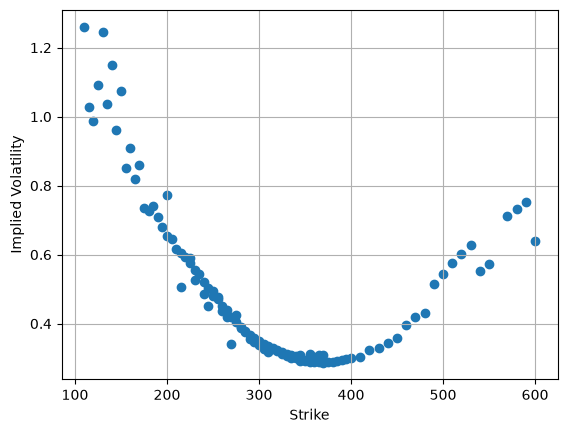

In [3]:
strikes = [p.strike for p in smile.points]
ivs = [p.implied_volatility for p in smile.points]

plt.scatter(strikes, ivs, label="Market Quotes")
plt.grid(True)
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")

In [4]:
#from optionanalytics.density import risk_neutral, _price
#density = risk_neutral.build_density(smile, market_data, valuation_date)

In [14]:
from optionanalytics.volatility.interpolation import interpolate_smile
from optionanalytics.utils.dates import year_fraction
from optionanalytics.pricing.black_scholes import black_scholes

from optionanalytics.models.density import Density, DensityPoint
from optionanalytics.models.volatility import VolatilitySmile
from optionanalytics.models.market import MarketData
from optionanalytics.models.enums import InterpolationMethod, OptionType
from optionanalytics.pricing.black_scholes import EuropeanOption

maturity = year_fraction(
    smile.expiry,
    valuation_date,
)

iv_function = interpolate_smile(
    smile,
    InterpolationMethod.PCHIP,
)

In [15]:
strikes = [p.strike for p in smile.points]

K = np.linspace(
    min(strikes),
    max(strikes),
    300,
)

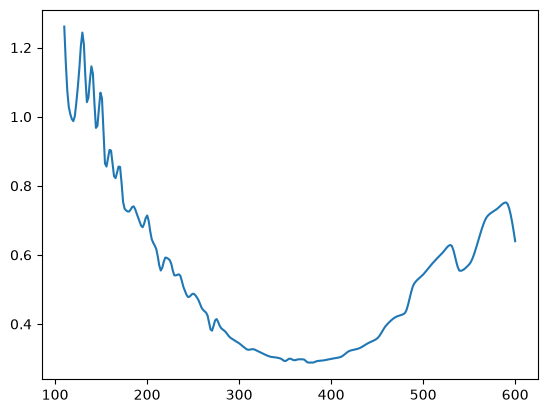

In [16]:
plt.plot(K, iv_function(K))

In [18]:
from optionanalytics.density.risk_neutral import _price_from_smile
C = np.array([
    _price_from_smile(
        k,
        iv_function,
        maturity,
        market_data,
    )
    for k in K
])

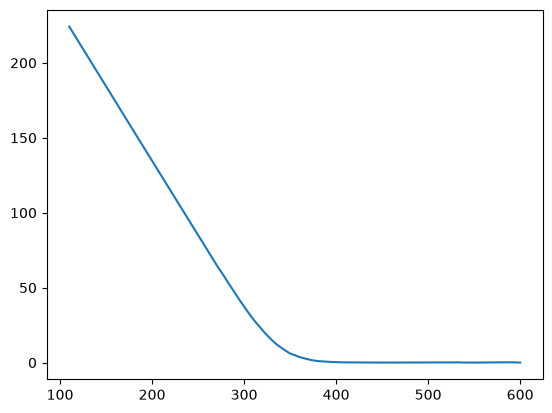

In [19]:
plt.plot(K, C)

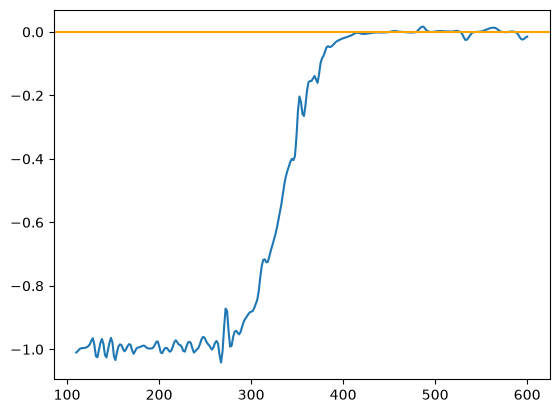

In [21]:
first = np.gradient(C, K)

plt.plot(K, first)
plt.axhline(0, color='orange')

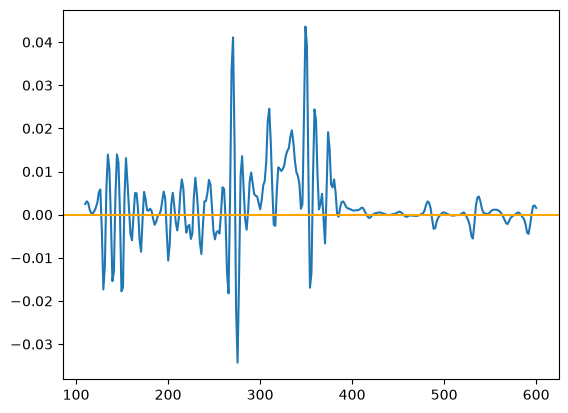

In [22]:
second = np.gradient(first, K)

plt.plot(K, second)
plt.axhline(0, color='orange')

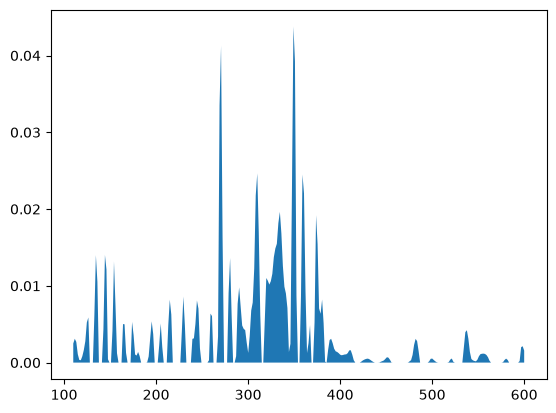

In [23]:
pdf = np.exp(
    market_data.risk_free_rate * maturity
) * second

pdf = np.maximum(pdf, 0)
plt.fill_between(K, pdf)

In [24]:
import numpy as np
area = np.trapezoid(pdf, K)

print(area) # Expected 1.000

1.695109618643726


In [ ]:
## Above area is not as per our expectations! We can establish that it arises from interpolation!
## Experiment 1: Establish that const vol validates the mathematical accuracy of Breeden-Litzenberger method.

## Experiment 1 — Constant Volatility Validation

Before analysing market implied volatilities, we first validate the
Breeden–Litzenberger implementation under a known setting.

If the implied volatility is constant across all strikes, the resulting
Black–Scholes call price surface is smooth and convex. The recovered
risk-neutral density should therefore:

- be smooth,
- remain non-negative,
- integrate to approximately one.

If this experiment succeeds, any instability observed later must arise
from the implied volatility interpolation rather than the density
extraction algorithm itself.

In [26]:
def constant_iv(_):
    return 0.20

maturity = year_fraction(smile.expiry, valuation_date)

strikes = [p.strike for p in smile.points]

K = np.linspace(
    min(strikes),
    max(strikes),
    300,
)

C = np.array([
    _price_from_smile(
        k,
        constant_iv,
        maturity,
        market_data,
    )
    for k in K
])

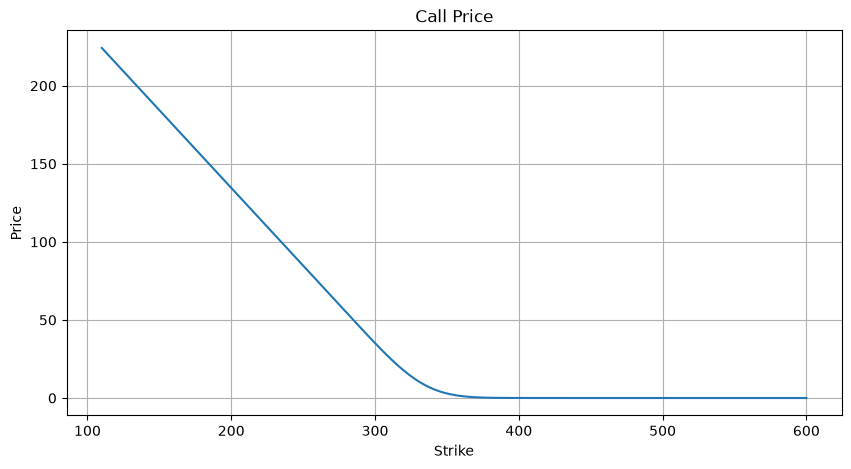

In [27]:
plt.figure(figsize=(10,5))

plt.plot(K, C)

plt.title("Call Price")
plt.xlabel("Strike")
plt.ylabel("Price")

plt.grid(True)

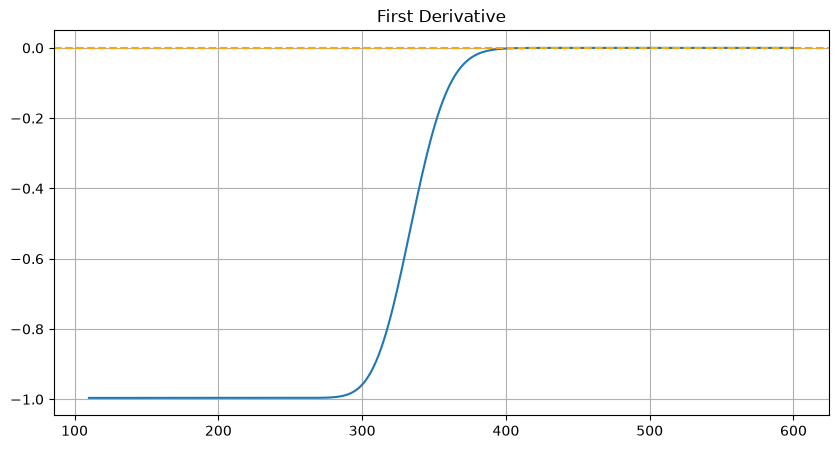

In [34]:
first = np.gradient(C, K)

plt.figure(figsize=(10,5))

plt.plot(K, first)
plt.axhline(0, color="orange", linestyle='--')

plt.title("First Derivative")
plt.grid(True)

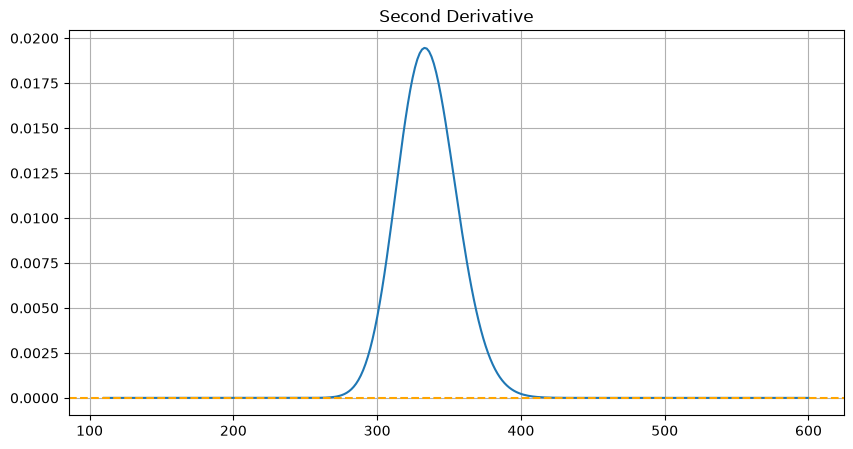

In [32]:
second = np.gradient(first, K)

plt.figure(figsize=(10,5))

plt.plot(K, second)
plt.axhline(0, color="orange", linestyle='--')

plt.title("Second Derivative")
plt.grid(True)

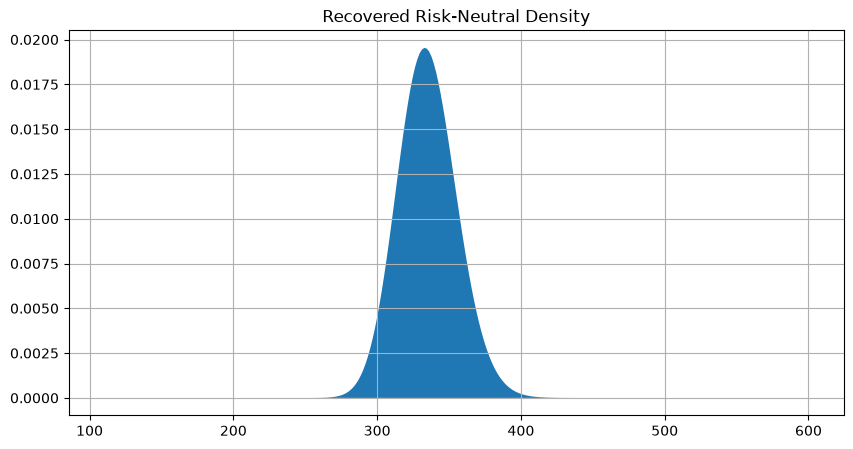

In [38]:
pdf = np.exp(
    market_data.risk_free_rate * maturity
) * second
pdf = np.maximum(pdf, 0.0)

plt.figure(figsize=(10,5))
plt.fill_between(K, pdf)
plt.title("Recovered Risk-Neutral Density")
plt.grid(True)

In [39]:
# Area under the curve
np.trapezoid(pdf, K)

np.float64(1.0000000000001492)

## Conclusion

The recovered density integrates to approximately one and exhibits the
expected smooth shape.

This validates

- Black–Scholes pricing,
- numerical differentiation,
- Breeden–Litzenberger implementation.

Any instability observed when using market implied volatilities must
therefore originate from the volatility smile representation rather than
the density extraction algorithm.